In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [2]:
import os
# Robust path resolver for data/ directory
data_path = next((p for p in ['../data/marketing_campaign.csv', 'data/marketing_campaign.csv', 'marketing_campaign.csv'] if os.path.exists(p)), 'marketing_campaign.csv')
df = pd.read_csv(data_path, sep='\t')
print(f'Dataset Loaded successfully from: {data_path}')
print('Dataset Shape:', df.shape)

Dataset Shape: (2240, 29)


In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [7]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
# Missing Values Analysis
df.isnull().sum().sort_values(ascending=False)

Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
# Remove Duplicates
print("Original dataset shape:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Original dataset shape: (2240, 29)
After removing duplicates: (2240, 29)


## Visual Exploratory Data Analysis (EDA)
Comprehensive investigation of customer demographics, purchasing channels, category expenditures, and campaign responsiveness.

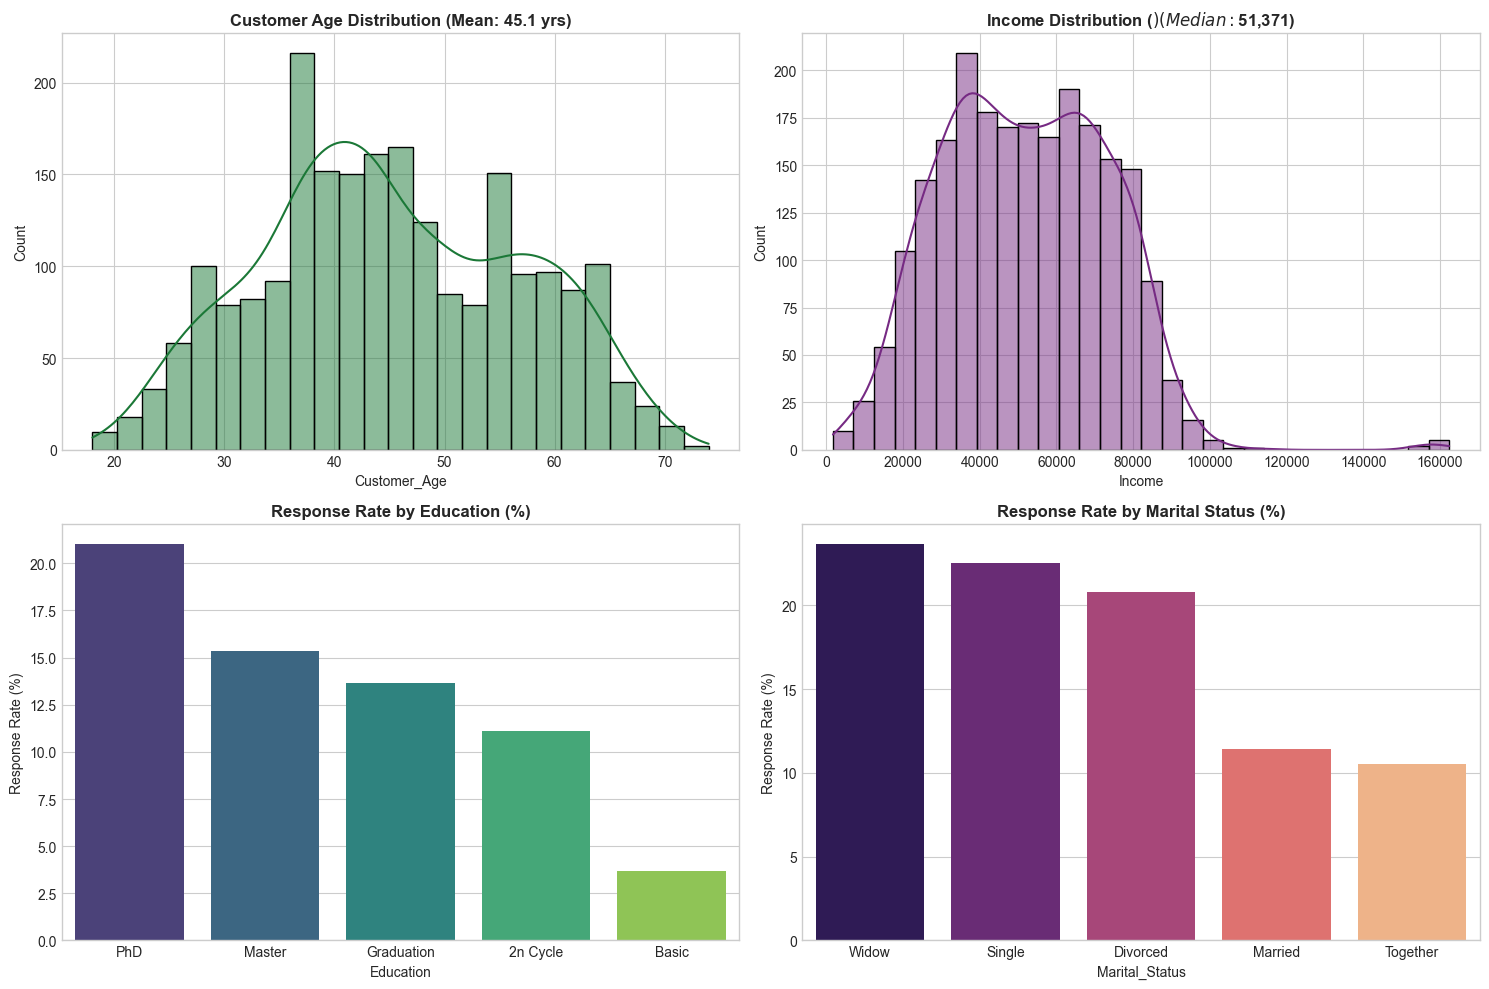

In [10]:
# 1. Demographic Distributions and Response Propensity
eda_df = df.copy()
eda_df['Customer_Age'] = 2014 - eda_df['Year_Birth']
clean_df = eda_df[(eda_df['Customer_Age'] <= 90) & (eda_df['Income'] < 200000)].dropna(subset=['Income']).copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(clean_df['Customer_Age'], kde=True, color="#1b7837", bins=25, ax=axes[0, 0])
axes[0, 0].set_title(f"Customer Age Distribution (Mean: {clean_df['Customer_Age'].mean():.1f} yrs)", weight="bold")

sns.histplot(clean_df['Income'], kde=True, color="#762a83", bins=30, ax=axes[0, 1])
axes[0, 1].set_title(f"Income Distribution ($) (Median: ${clean_df['Income'].median():,.0f})", weight="bold")

edu_resp = clean_df.groupby("Education")["Response"].mean().reset_index()
edu_resp["Response"] *= 100
sns.barplot(x="Education", y="Response", data=edu_resp.sort_values("Response", ascending=False),
            ax=axes[1, 0], palette="viridis", hue="Education", legend=False)
axes[1, 0].set_title("Response Rate by Education (%)", weight="bold")
axes[1, 0].set_ylabel("Response Rate (%)")

marital_top = clean_df["Marital_Status"].value_counts().index[:5]
marital_resp = clean_df[clean_df["Marital_Status"].isin(marital_top)].groupby("Marital_Status")["Response"].mean().reset_index()
marital_resp["Response"] *= 100
sns.barplot(x="Marital_Status", y="Response", data=marital_resp.sort_values("Response", ascending=False),
            ax=axes[1, 1], palette="magma", hue="Marital_Status", legend=False)
axes[1, 1].set_title("Response Rate by Marital Status (%)", weight="bold")
axes[1, 1].set_ylabel("Response Rate (%)")

plt.tight_layout()
plt.show()

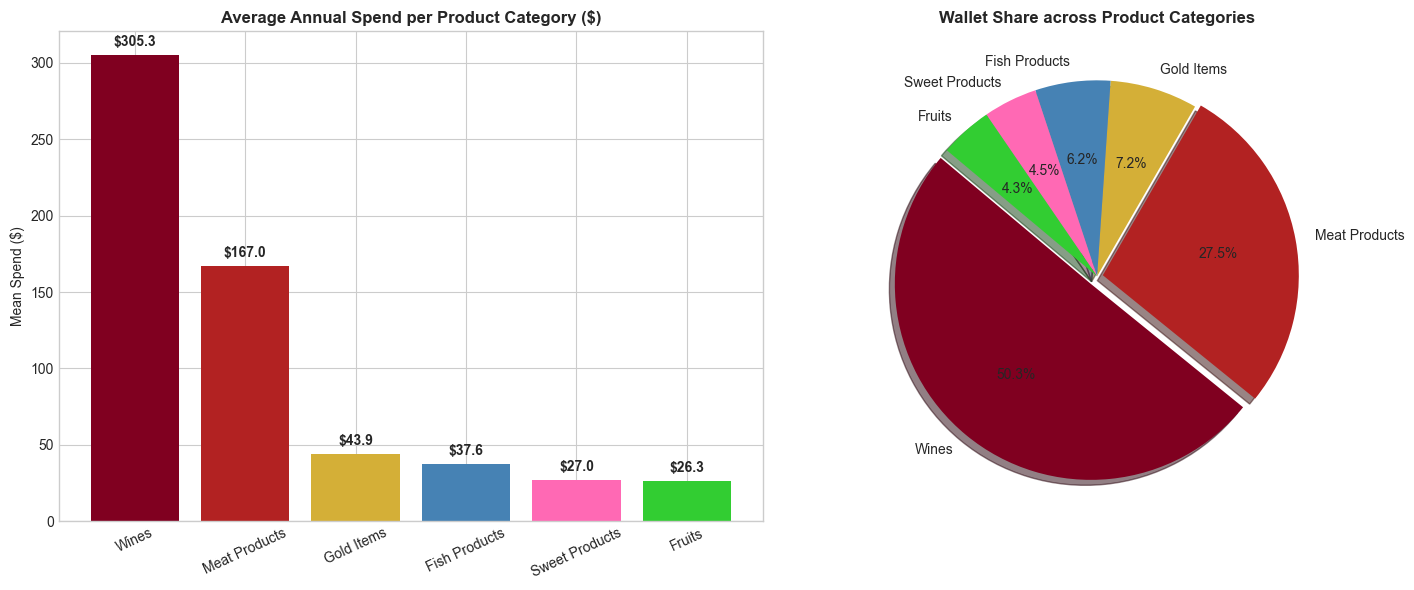

In [11]:
# 2. Spending Breakdown by Category
spending_cols = ["MntWines", "MntMeatProducts", "MntGoldProds", "MntFishProducts", "MntSweetProducts", "MntFruits"]
spending_names = ["Wines", "Meat Products", "Gold Items", "Fish Products", "Sweet Products", "Fruits"]
mean_spend = [clean_df[col].mean() for col in spending_cols]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].bar(spending_names, mean_spend, color=["#800020", "#b22222", "#d4af37", "#4682b4", "#ff69b4", "#32cd32"])
axes[0].set_title("Average Annual Spend per Product Category ($)", weight="bold")
axes[0].set_ylabel("Mean Spend ($)")
axes[0].tick_params(axis='x', rotation=25)
for bar in bars:
    axes[0].annotate(f"${bar.get_height():.1f}", (bar.get_x() + bar.get_width() / 2., bar.get_height() + 4),
                     ha='center', va='bottom', weight='bold')

axes[1].pie(mean_spend, labels=spending_names, autopct="%1.1f%%", startangle=140,
            colors=["#800020", "#b22222", "#d4af37", "#4682b4", "#ff69b4", "#32cd32"],
            explode=[0.05, 0.03, 0, 0, 0, 0], shadow=True)
axes[1].set_title("Wallet Share across Product Categories", weight="bold")

plt.tight_layout()
plt.show()

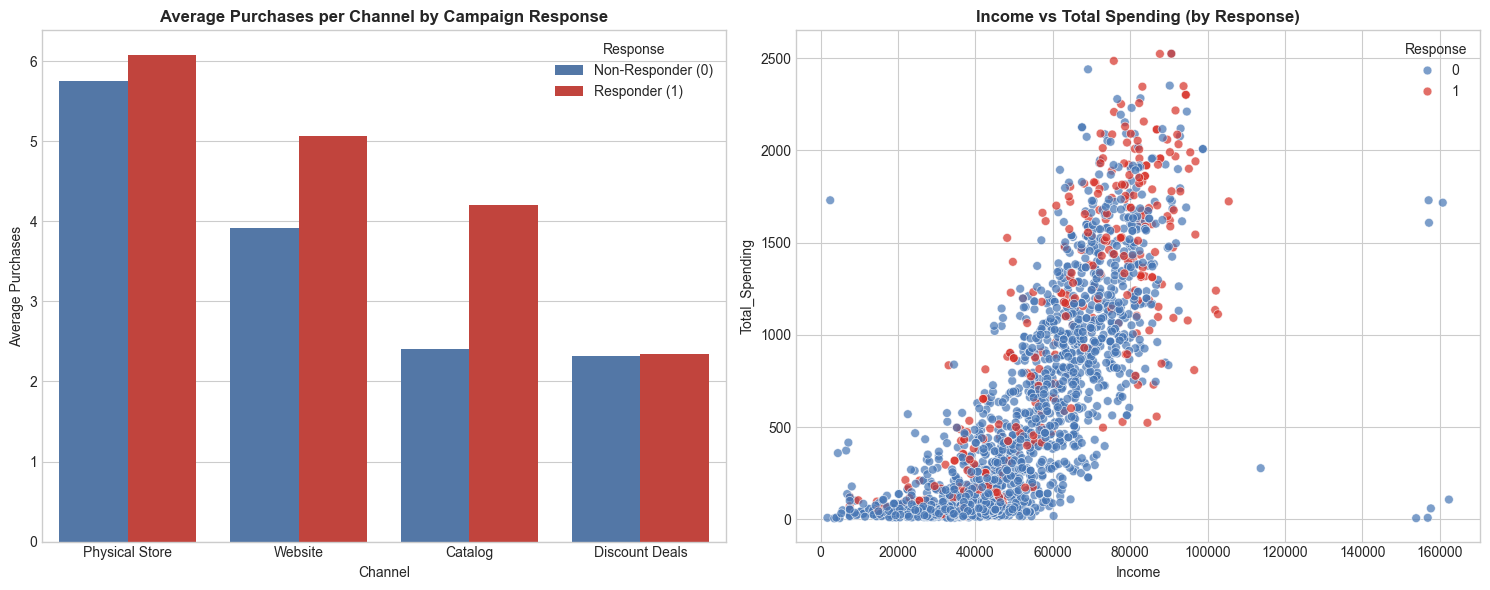

In [12]:
# 3. Purchasing Channels & Response Correlation
clean_df["Total_Spending"] = (clean_df["MntWines"] + clean_df["MntFruits"] + clean_df["MntMeatProducts"] +
                              clean_df["MntFishProducts"] + clean_df["MntSweetProducts"] + clean_df["MntGoldProds"])
channel_cols = ["NumStorePurchases", "NumWebPurchases", "NumCatalogPurchases", "NumDealsPurchases"]
channel_labels = ["Physical Store", "Website", "Catalog", "Discount Deals"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

channel_df = clean_df.groupby("Response")[channel_cols].mean().reset_index()
channel_df_melt = pd.melt(channel_df, id_vars=["Response"], value_vars=channel_cols,
                          var_name="Channel", value_name="Average Purchases")
channel_df_melt["Channel"] = channel_df_melt["Channel"].replace(dict(zip(channel_cols, channel_labels)))
channel_df_melt["Response"] = channel_df_melt["Response"].map({0: "Non-Responder (0)", 1: "Responder (1)"})

sns.barplot(x="Channel", y="Average Purchases", hue="Response", data=channel_df_melt,
            palette=["#4575b4", "#d73027"], ax=axes[0])
axes[0].set_title("Average Purchases per Channel by Campaign Response", weight="bold")

sns.scatterplot(data=clean_df, x="Income", y="Total_Spending", hue="Response",
                palette=["#4575b4", "#d73027"], alpha=0.7, s=40, ax=axes[1])
axes[1].set_title("Income vs Total Spending (by Response)", weight="bold")

plt.tight_layout()
plt.show()

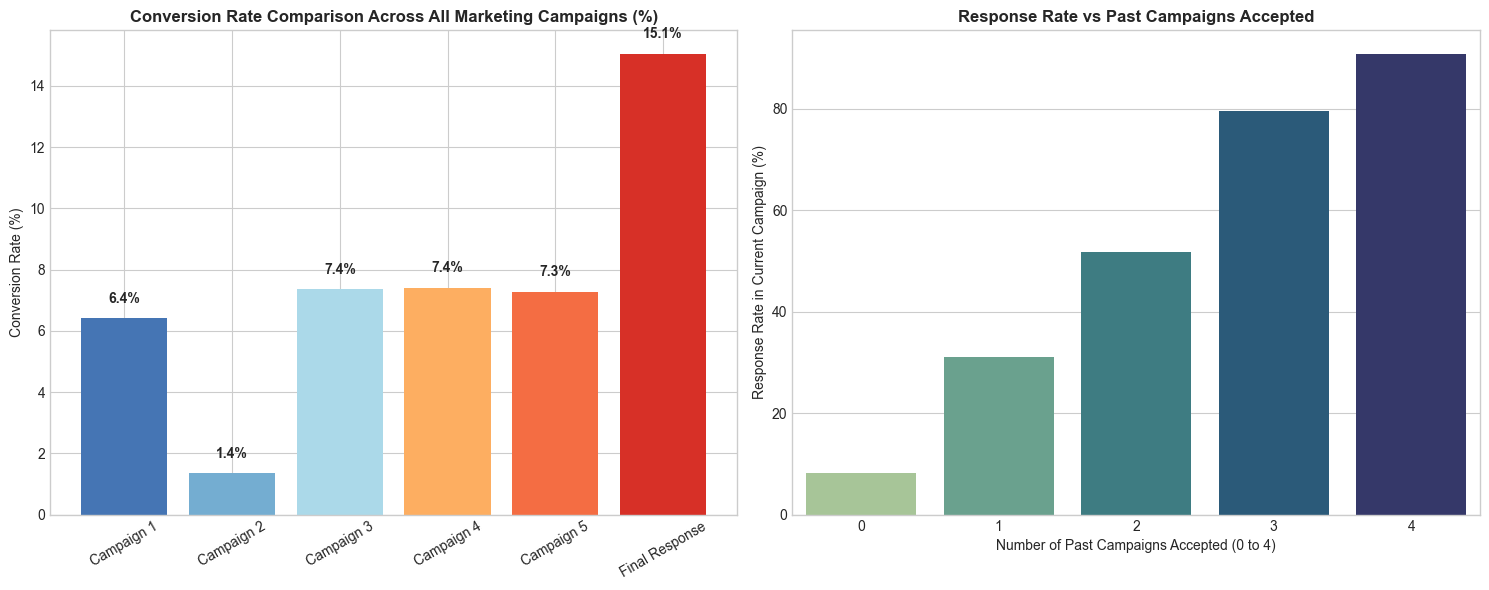

In [13]:
# 4. Campaign History & Multi-Campaign Acceptance
clean_df["Total_Accepted_Campaigns"] = (clean_df["AcceptedCmp1"] + clean_df["AcceptedCmp2"] +
                                       clean_df["AcceptedCmp3"] + clean_df["AcceptedCmp4"] +
                                       clean_df["AcceptedCmp5"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]
cmp_names = ["Campaign 1", "Campaign 2", "Campaign 3", "Campaign 4", "Campaign 5", "Final Response"]
cmp_rates = [clean_df[col].mean() * 100 for col in cmp_cols]

bars = axes[0].bar(cmp_names, cmp_rates, color=["#4575b4", "#74add1", "#abd9e9", "#fdae61", "#f46d43", "#d73027"])
axes[0].set_title("Conversion Rate Comparison Across All Marketing Campaigns (%)", weight="bold")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[0].annotate(f"{bar.get_height():.1f}%", (bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.4),
                     ha='center', va='bottom', weight='bold')

accum_resp = clean_df.groupby("Total_Accepted_Campaigns")["Response"].mean().reset_index()
accum_resp["Response"] *= 100
sns.barplot(x="Total_Accepted_Campaigns", y="Response", data=accum_resp, palette="crest", ax=axes[1], hue="Total_Accepted_Campaigns", legend=False)
axes[1].set_title("Response Rate vs Past Campaigns Accepted", weight="bold")
axes[1].set_xlabel("Number of Past Campaigns Accepted (0 to 4)")
axes[1].set_ylabel("Response Rate in Current Campaign (%)")

plt.tight_layout()
plt.show()

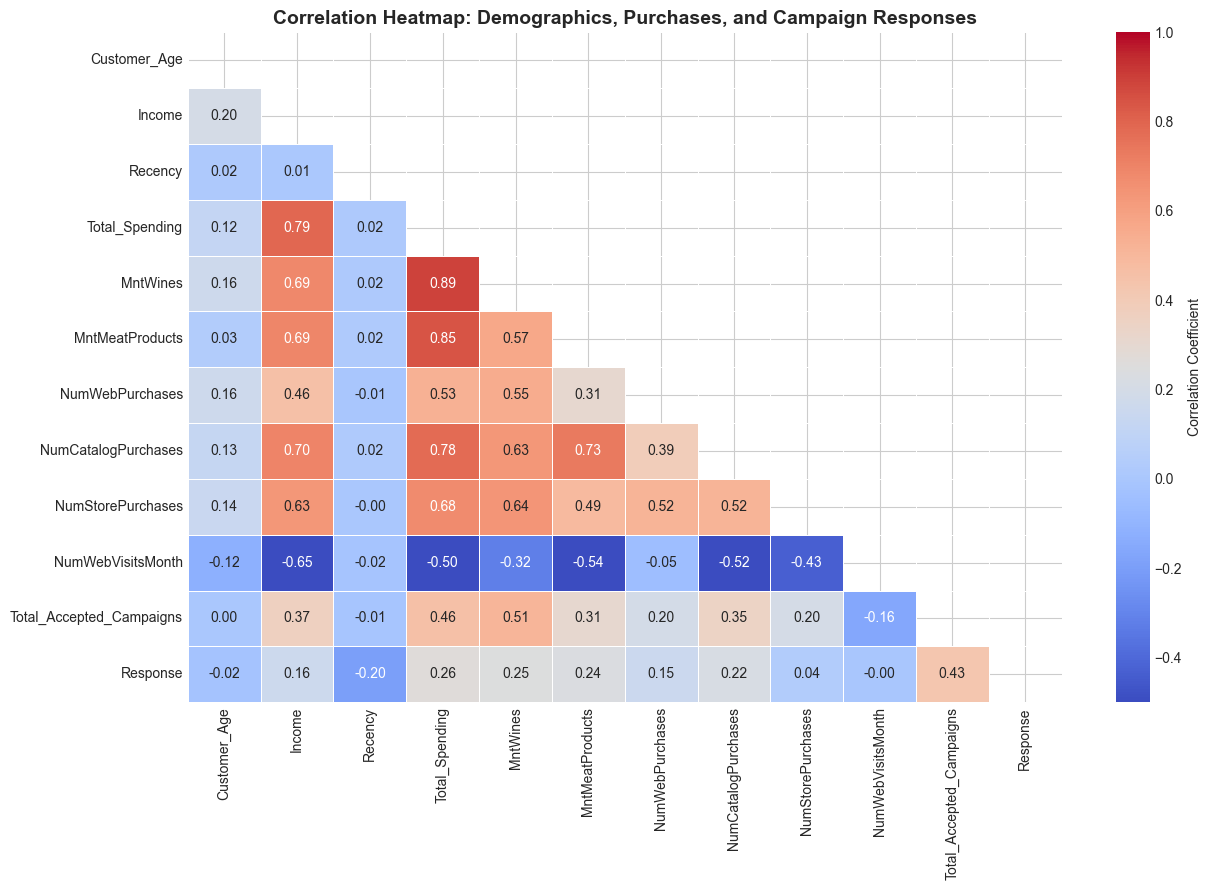

In [14]:
# 5. Correlation Heatmap for Key Marketing Metrics
plt.figure(figsize=(13, 9))
key_vars = [
    "Customer_Age", "Income", "Recency", "Total_Spending", "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "Total_Accepted_Campaigns", "Response"
]
corr_mc = clean_df[key_vars].corr()
mask = np.triu(np.ones_like(corr_mc, dtype=bool))
sns.heatmap(corr_mc, annot=True, fmt=".2f", cmap="coolwarm", vmin=-0.5, vmax=1.0,
            mask=mask, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Correlation Heatmap: Demographics, Purchases, and Campaign Responses", weight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
X_raw = df.drop(columns=["Response"])
y = df["Response"]

In [16]:
def engineer_features(df_in):
    d = df_in.copy()
    d = d.drop(columns=["ID", "Z_CostContact", "Z_Revenue", "Customer_Age"], errors="ignore")
    d["Age"] = (2015 - d["Year_Birth"]).clip(lower=18, upper=100)
    d = d.drop(columns=["Year_Birth"], errors="ignore")
    dt_parsed = pd.to_datetime(d["Dt_Customer"], format="%d-%m-%Y", errors="coerce")
    ref_date = pd.to_datetime("2015-01-01")
    d["Customer_Tenure_Days"] = (ref_date - dt_parsed).dt.days
    d["Enrollment_Year"] = dt_parsed.dt.year
    d = d.drop(columns=["Dt_Customer"], errors="ignore")
    d["Total_Children"] = d["Kidhome"] + d["Teenhome"]
    d["Is_Parent"] = (d["Total_Children"] > 0).astype(int)
    d["Total_Spend"] = (
        d["MntWines"] + d["MntFruits"] + d["MntMeatProducts"] +
        d["MntFishProducts"] + d["MntSweetProducts"] + d["MntGoldProds"]
    )
    d["Total_Purchases"] = (
        d["NumWebPurchases"] + d["NumCatalogPurchases"] +
        d["NumStorePurchases"] + d["NumDealsPurchases"]
    )
    d["Total_Accepted_Cmp"] = (
        d["AcceptedCmp1"] + d["AcceptedCmp2"] + d["AcceptedCmp3"] +
        d["AcceptedCmp4"] + d["AcceptedCmp5"]
    )
    d["Spend_Per_Purchase"] = d["Total_Spend"] / (d["Total_Purchases"] + 1)
    return d

In [17]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training instances: {X_train_raw.shape[0]} (Positive Response: {y_train.mean()*100:.1f}%)")
print(f"Testing instances:  {X_test_raw.shape[0]} (Positive Response: {y_test.mean()*100:.1f}%)")

Training instances: 1792 (Positive Response: 14.9%)
Testing instances:  448 (Positive Response: 15.0%)


In [18]:
X_train = engineer_features(X_train_raw)
X_test  = engineer_features(X_test_raw)
print("Engineered feature shapes:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

Engineered feature shapes:
X_train: (1792, 32)
X_test:  (448, 32)


In [19]:
all_numeric = X_train.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()
categorical_features = ["Education", "Marital_Status"]

# Automatically separate binary indicator features (0/1) from continuous numeric features
binary_features = [col for col in all_numeric if set(X_train[col].dropna().unique()).issubset({0, 1})]
continuous_numeric = [col for col in all_numeric if col not in binary_features]

print(f"Continuous numerical features ({len(continuous_numeric)}):", continuous_numeric)
print(f"Binary indicator features ({len(binary_features)}):", binary_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)

Continuous numerical features (23): ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Customer_Tenure_Days', 'Enrollment_Year', 'Total_Children', 'Total_Spend', 'Total_Purchases', 'Total_Accepted_Cmp', 'Spend_Per_Purchase']
Binary indicator features (7): ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Is_Parent']
Categorical features (2): ['Education', 'Marital_Status']


In [20]:
# Temporary copy for calculating skewness on continuous numerical features
X_train_cont = X_train[continuous_numeric].copy()
# Median imputation ONLY for calculating skewness
X_train_cont = X_train_cont.fillna(X_train_cont.median())
skewness = X_train_cont.skew()
print("\nSkewness of continuous numerical features:")
print(skewness.sort_values(ascending=False))


Skewness of continuous numerical features:
Spend_Per_Purchase      8.771962
Income                  7.514169
Total_Accepted_Cmp      2.747300
NumDealsPurchases       2.527377
MntSweetProducts        2.168735
MntFruits               2.109262
MntMeatProducts         2.082342
MntGoldProds            1.937007
MntFishProducts         1.922279
NumCatalogPurchases     1.867404
NumWebPurchases         1.494817
MntWines                1.191431
Total_Spend             0.848374
NumStorePurchases       0.706807
Kidhome                 0.630798
Teenhome                0.429745
Total_Children          0.424584
NumWebVisitsMonth       0.319386
Total_Purchases         0.262865
Age                     0.152996
Recency                 0.013020
Enrollment_Year        -0.029156
Customer_Tenure_Days   -0.042740
dtype: float64


In [21]:
log_features = []
for col in continuous_numeric:
    if X_train_cont[col].min() >= 0:
        if abs(skewness[col]) > 1:
            log_features.append(col)
regular_numeric_features = [
    col
    for col in continuous_numeric
    if col not in log_features
]
print("\nLog-transformed features:", log_features)
print("\nRegular numerical features:", regular_numeric_features)
print("\nBinary features (passthrough without scaling):", binary_features)


Log-transformed features: ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'Total_Accepted_Cmp', 'Spend_Per_Purchase']

Regular numerical features: ['Kidhome', 'Teenhome', 'Recency', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Customer_Tenure_Days', 'Enrollment_Year', 'Total_Children', 'Total_Spend', 'Total_Purchases']

Binary features (passthrough without scaling): ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Is_Parent']


In [22]:
# Preprocessing Pipelines & ColumnTransformer
log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", RobustScaler())
])

regular_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("log_numeric", log_numeric_pipeline, log_features),
    ("regular_numeric", regular_numeric_pipeline, regular_numeric_features),
    ("binary", binary_pipeline, binary_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [23]:
# Curated Models
models = {
    "Logistic Regression (Propensity Baseline)": LogisticRegression(C=0.8, class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest Classifier (Bagging)": RandomForestClassifier(n_estimators=150, max_depth=6, min_samples_leaf=2, class_weight='balanced', random_state=42),
    "Gradient Boosting Classifier (Boosting Champion)": GradientBoostingClassifier(n_estimators=120, learning_rate=0.06, max_depth=3, subsample=0.8, random_state=42)
}

In [24]:
# 8. Train, Cross-Validate, Predict, and Evaluate Curated Classification Pipelines
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, classifier in models.items():
    model = Pipeline([("preprocessing", preprocessor), ("classifier", classifier)])
    
    # 5-Fold Stratified Cross-Validation on Training Set
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=["roc_auc", "f1", "accuracy"])
    cv_roc_mean = cv_scores["test_roc_auc"].mean()
    cv_roc_std = cv_scores["test_roc_auc"].std()
    cv_f1_mean = cv_scores["test_f1"].mean()
    cv_acc_mean = cv_scores["test_accuracy"].mean()
    
    # Final fit on full training set and evaluate on Hold-out Test Set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    print("\n======================================")
    print(f" {name} Results")
    print("======================================")
    print(f"5-Fold CV Accuracy: {cv_acc_mean * 100:.2f}%")
    print(f"5-Fold CV F1-Score: {cv_f1_mean * 100:.2f}%")
    print(f"5-Fold CV ROC-AUC : {cv_roc_mean:.4f} (+/- {cv_roc_std:.4f})")
    print(f"Test Accuracy     : {accuracy * 100:.2f}%")
    print(f"Test Precision    : {precision * 100:.2f}%")
    print(f"Test Recall       : {recall * 100:.2f}%")
    print(f"Test F1-Score     : {f1 * 100:.2f}%")
    print(f"Test ROC-AUC      : {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    
    results.append({
        "Model": name,
        "CV ROC-AUC": f"{cv_roc_mean:.4f} (±{cv_roc_std:.3f})",
        "Test ROC-AUC": f"{roc_auc:.4f}",
        "Test F1-Score (%)": f"{f1 * 100:.2f}%",
        "Test Accuracy (%)": f"{accuracy * 100:.2f}%",
        "Test Precision (%)": f"{precision * 100:.2f}%",
        "Test Recall (%)": f"{recall * 100:.2f}%"
    })


 Logistic Regression (Propensity Baseline) Results
5-Fold CV Accuracy: 83.54%
5-Fold CV F1-Score: 59.53%
5-Fold CV ROC-AUC : 0.9096 (+/- 0.0195)
Test Accuracy     : 84.15%
Test Precision    : 48.11%
Test Recall       : 76.12%
Test F1-Score     : 58.96%
Test ROC-AUC      : 0.9071

Confusion Matrix:
[[326  55]
 [ 16  51]]

 Random Forest Classifier (Bagging) Results
5-Fold CV Accuracy: 82.53%
5-Fold CV F1-Score: 55.32%
5-Fold CV ROC-AUC : 0.8804 (+/- 0.0302)
Test Accuracy     : 81.47%
Test Precision    : 42.45%
Test Recall       : 67.16%
Test F1-Score     : 52.02%
Test ROC-AUC      : 0.8678

Confusion Matrix:
[[320  61]
 [ 22  45]]

 Gradient Boosting Classifier (Boosting Champion) Results
5-Fold CV Accuracy: 88.56%
5-Fold CV F1-Score: 51.75%
5-Fold CV ROC-AUC : 0.8956 (+/- 0.0197)
Test Accuracy     : 89.96%
Test Precision    : 84.38%
Test Recall       : 40.30%
Test F1-Score     : 54.55%
Test ROC-AUC      : 0.9022

Confusion Matrix:
[[376   5]
 [ 40  27]]


In [25]:
# 9. Consolidated Summary Table
summary_df = pd.DataFrame(results).sort_values(by="Test ROC-AUC", ascending=False)
print("\n==================================== FINAL MODEL PERFORMANCE RANKING ====================================")
print(summary_df.to_string(index=False))


==================================== FINAL MODEL PERFORMANCE RANKING ====================================
                                           Model      CV ROC-AUC Test ROC-AUC Test F1-Score (%) Test Accuracy (%) Test Precision (%) Test Recall (%)
       Logistic Regression (Propensity Baseline) 0.9096 (±0.020)       0.9071            58.96%            84.15%             48.11%          76.12%
Gradient Boosting Classifier (Boosting Champion) 0.8956 (±0.020)       0.9022            54.55%            89.96%             84.38%          40.30%
              Random Forest Classifier (Bagging) 0.8804 (±0.030)       0.8678            52.02%            81.47%             42.45%          67.16%
